In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm


2025-02-16 13:02:28.670557: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [3]:
def build_regularized_model():
    model = Sequential([
        Dense(512, activation="relu", input_shape=(784,), 
              kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4), kernel_constraint=max_norm(3)),
        Dropout(0.3),
        Dense(256, activation="relu", 
              kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4), kernel_constraint=max_norm(3)),
        Dropout(0.3),
        Dense(128, activation="relu", 
              kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4), kernel_constraint=max_norm(3)),
        Dense(10, activation="softmax")
    ])
    return model


In [4]:
model = build_regularized_model()
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=["accuracy"])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 567,434


2025-02-16 13:04:58.742319: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Trainable params: 567,434
Non-trainable params: 0
_________________________________________________________________


In [5]:
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_test, y_test))


Epoch 1/20
469/469 [==============================] - 13s 23ms/step - loss: 0.5516 - accuracy: 0.9064 - val_loss: 0.3441 - val_accuracy: 0.9618
Epoch 2/20
469/469 [==============================] - 10s 21ms/step - loss: 0.3446 - accuracy: 0.9596 - val_loss: 0.2858 - val_accuracy: 0.9725
Epoch 3/20
469/469 [==============================] - 11s 24ms/step - loss: 0.2984 - accuracy: 0.9669 - val_loss: 0.2615 - val_accuracy: 0.9760
Epoch 4/20
469/469 [==============================] - 10s 22ms/step - loss: 0.2715 - accuracy: 0.9708 - val_loss: 0.2498 - val_accuracy: 0.9772
Epoch 5/20
469/469 [==============================] - 10s 22ms/step - loss: 0.2513 - accuracy: 0.9739 - val_loss: 0.2350 - val_accuracy: 0.9773
Epoch 6/20
469/469 [==============================] - 11s 24ms/step - loss: 0.2385 - accuracy: 0.9747 - val_loss: 0.2257 - val_accuracy: 0.9764
Epoch 7/20
469/469 [==============================] - 12s 25ms/step - loss: 0.2277 - accuracy: 0.9763 - val_loss: 0.2192 - val_accuracy:

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


313/313 [==============================] - 1s 5ms/step - loss: 0.1747 - accuracy: 0.9830
Test Accuracy: 0.9830


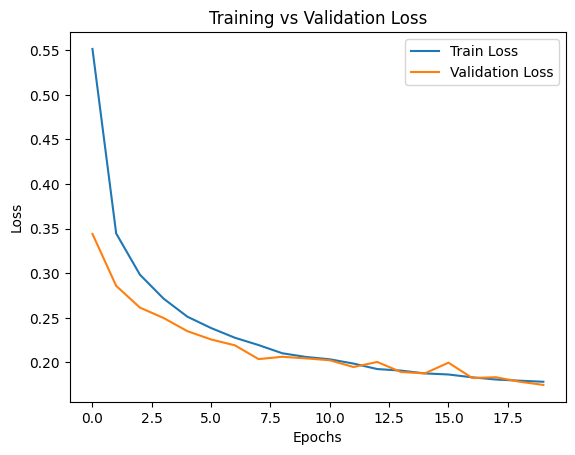

In [7]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


2

In [9]:
pip install tensorflow-datasets

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 5.0 MB 6.0 MB/s eta 0:00:01     |█▊                              | 276 kB 2.1 MB/s eta 0:00:03
     |████████████████████████████████| 115 kB 7.5 MB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 8.1 MB/s eta 0:00:01
     |████████████████████████████████| 140 kB 10.9 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 5.7 MB/s eta 0:00:01
     |████████████████████████████████| 417 kB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 14.5 MB/s eta 0:00:01
     |████████████████████████████████| 184 kB 3.3 MB/s eta 0:00:01
     |████████████████████████████████| 982 kB 5.0 MB/s eta 0:00:01
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21502 sha256=6fa1b5a86325ddaaebf04adc8bcbeca9b040f4319292f31709c5710bacd0e4bb
  Stored in directory: /Users/stefenkaushik/Library/Caches/pip/wheels/e1/e8/83/ddea66100678d1

In [10]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds


from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast


/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:

dataset_name = "tf_flowers"
(ds_train, ds_val), ds_info = tfds.load(dataset_name, split=["train[:80%]", "train[80%:]"], as_supervised=True, with_info=True)


class_names = ds_info.features["label"].names
print(f"Dataset classes: {class_names}")


2025-02-16 13:17:12.405467: W tensorflow/core/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata".


Dl Completed...: 100%|██████████| 5/5 [00:44<00:00,  8.93s/ file]


Dataset tf_flowers downloaded and prepared to /Users/stefenkaushik/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [12]:
IMG_SIZE = 224  

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) 
    image = image / 255.0  
    return image, label

ds_train = ds_train.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


In [13]:
data_augmentation = keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
])


ds_train_augmented = ds_train.map(lambda x, y: (data_augmentation(x, training=True), y))


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [14]:
class CustomAugmentationLayer(keras.layers.Layer):
    def __init__(self):
        super().__init__()

    def call(self, images):
        images = tf.image.random_brightness(images, 0.2)  
        images = tf.image.random_saturation(images, 0.5, 1.5)  
        images = tf.image.random_hue(images, 0.2)  
        images = tf.image.random_contrast(images, 0.5, 1.5)  
        return images

custom_augmentation = CustomAugmentationLayer()
ds_train_custom_augmented = ds_train.map(lambda x, y: (custom_augmentation(x), y))


In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D


base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False 


model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation, 
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(len(class_names), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(ds_train_augmented, epochs=10, validation_data=ds_val)


9406464/9406464 [==============================] - 3s 0us/step


Epoch 1/10


92/92 [==============================] - 232s 2s/step - loss: 0.6667 - accuracy: 0.7527 - val_loss: 0.3947 - val_accuracy: 0.8678
Epoch 2/10
92/92 [==============================] - 223s 2s/step - loss: 0.4464 - accuracy: 0.8341 - val_loss: 0.4133 - val_accuracy: 0.8460
Epoch 3/10
92/92 [==============================] - 250s 3s/step - loss: 0.3827 - accuracy: 0.8600 - val_loss: 0.3663 - val_accuracy: 0.8842
Epoch 4/10
92/92 [==============================] - 277s 3s/step - loss: 0.3486 - accuracy: 0.8651 - val_loss: 0.4135 - val_accuracy: 0.8624
Epoch 5/10
92/92 [==============================] - 277s 3s/step - loss: 0.3342 - accuracy: 0.8757 - val_loss: 0.3277 - val_accuracy: 0.8910
Epoch 6/10
92/92 [==============================] - 288s 3s/step - loss: 0.3019 - accuracy: 0.8869 - val_loss: 0.3514 - val_accuracy: 0.8842
Epoch 7/10
92/92 [==============================] - 304s 3s/step - loss: 0.2918 - accuracy: 0.8886 - val_loss: 0.3257 - val_accuracy: 0.9019
Epoch 8/10
92/92 [======

In [16]:
test_loss, test_acc = model.evaluate(ds_val)
print(f"Test Accuracy: {test_acc:.4f}")


23/23 [==============================] - 31s 1s/step - loss: 0.3362 - accuracy: 0.9101
Test Accuracy: 0.9101


3

In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.models import Model


In [18]:

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

valid_classes = [0, 1, 2, 3, 5, 6, 8, 9]  
train_mask = np.isin(y_train, valid_classes).flatten()
test_mask = np.isin(y_test, valid_classes).flatten()

X_train, y_train = X_train[train_mask], y_train[train_mask]
X_test, y_test = X_test[test_mask], y_test[test_mask]

label_map = {orig_label: new_label for new_label, orig_label in enumerate(valid_classes)}
y_train = np.vectorize(label_map.get)(y_train)
y_test = np.vectorize(label_map.get)(y_test)

y_train_binary = np.where(y_train < 2, 0, 1)  
y_test_binary = np.where(y_test < 2, 0, 1)

X_train, X_test = X_train / 255.0, X_test / 255.0


In [19]:
def build_multi_task_model():
    inputs = Input(shape=(32, 32, 3)) 

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    multi_class_output = Dense(8, activation='softmax', name='multi_class_output')(x)

    binary_output = Dense(1, activation='sigmoid', name='binary_output')(x)

    model = Model(inputs=inputs, outputs=[multi_class_output, binary_output])
    return model

model = build_multi_task_model()
model.compile(optimizer='adam',
              loss={'multi_class_output': 'sparse_categorical_crossentropy', 'binary_output': 'binary_crossentropy'},
              metrics={'multi_class_output': 'accuracy', 'binary_output': 'accuracy'})

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 32)   896         ['input_3[0][0]']                
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 16, 16, 32)   0           ['conv2d[0][0]']                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 16, 16, 64)   18496       ['max_pooling2d[0][0]']          
                                                                                              

In [20]:
history = model.fit(X_train, {'multi_class_output': y_train, 'binary_output': y_train_binary},
                    validation_data=(X_test, {'multi_class_output': y_test, 'binary_output': y_test_binary}),
                    epochs=20, batch_size=64)


Epoch 1/20
625/625 [==============================] - 106s 165ms/step - loss: 1.6961 - multi_class_output_loss: 1.3016 - binary_output_loss: 0.3945 - multi_class_output_accuracy: 0.5002 - binary_output_accuracy: 0.8153 - val_loss: 1.3706 - val_multi_class_output_loss: 1.0266 - val_binary_output_loss: 0.3440 - val_multi_class_output_accuracy: 0.6234 - val_binary_output_accuracy: 0.8413
Epoch 2/20
625/625 [==============================] - 108s 173ms/step - loss: 1.2311 - multi_class_output_loss: 0.9342 - binary_output_loss: 0.2969 - multi_class_output_accuracy: 0.6582 - binary_output_accuracy: 0.8708 - val_loss: 1.1635 - val_multi_class_output_loss: 0.8950 - val_binary_output_loss: 0.2685 - val_multi_class_output_accuracy: 0.6687 - val_binary_output_accuracy: 0.8880
Epoch 3/20
625/625 [==============================] - 118s 188ms/step - loss: 1.0381 - multi_class_output_loss: 0.7905 - binary_output_loss: 0.2477 - multi_class_output_accuracy: 0.7116 - binary_output_accuracy: 0.8963 - val

In [21]:
test_loss, test_multi_class_loss, test_binary_loss, test_multi_class_acc, test_binary_acc = model.evaluate(
    X_test, {'multi_class_output': y_test, 'binary_output': y_test_binary}
)

print(f"\nMulti-Class Accuracy: {test_multi_class_acc:.4f}")
print(f"Binary Classification Accuracy: {test_binary_acc:.4f}")


250/250 [==============================] - 8s 30ms/step - loss: 1.7763 - multi_class_output_loss: 1.3559 - binary_output_loss: 0.4204 - multi_class_output_accuracy: 0.7630 - binary_output_accuracy: 0.9221

Multi-Class Accuracy: 0.7630
Binary Classification Accuracy: 0.9221


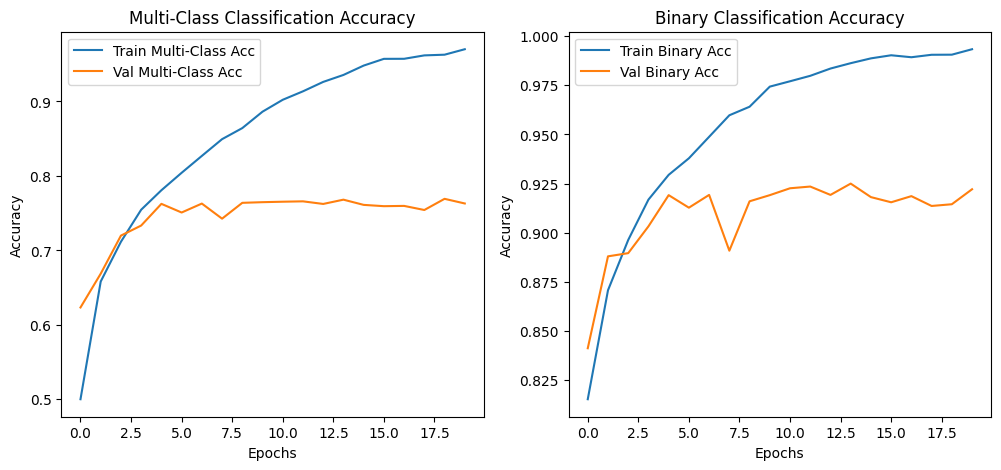

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['multi_class_output_accuracy'], label='Train Multi-Class Acc')
plt.plot(history.history['val_multi_class_output_accuracy'], label='Val Multi-Class Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Multi-Class Classification Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['binary_output_accuracy'], label='Train Binary Acc')
plt.plot(history.history['val_binary_output_accuracy'], label='Val Binary Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Binary Classification Accuracy')

plt.show()


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [24]:

X, y = make_blobs(n_samples=1000, centers=3, cluster_std=2.0, random_state=42)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Label"] = y

y_categorical = pd.get_dummies(df["Label"]).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (800, 2), y_train shape: (800,)
X_test shape: (200, 2), y_test shape: (200,)


In [25]:
def ensemble_predict(models, X):
    """Generate predictions using majority voting from multiple models."""
    predictions = np.array([model.predict(X) for model in models])
    final_prediction = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
    return final_prediction


In [26]:
def evaluate_ensemble(n_models):
    """Train and evaluate an ensemble of decision trees."""
    models = []
    
    for _ in range(n_models):
        X_sample, y_sample = X_train, y_train  
        model = DecisionTreeClassifier(max_depth=5)
        model.fit(X_sample, y_sample)
        models.append(model)

    y_pred = ensemble_predict(models, X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


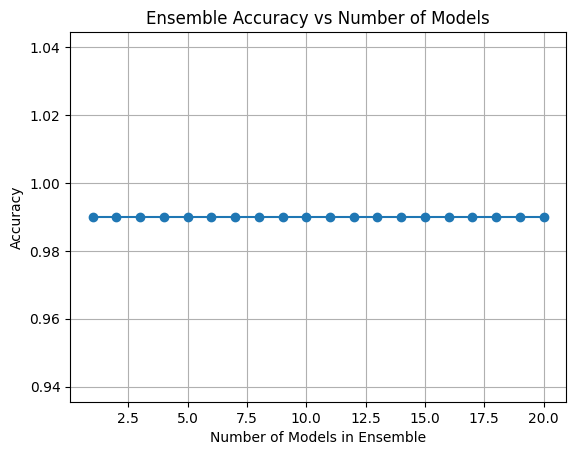

In [27]:
ensemble_sizes = list(range(1, 21))  
scores = [evaluate_ensemble(n) for n in ensemble_sizes]

plt.plot(ensemble_sizes, scores, marker='o')
plt.xlabel("Number of Models in Ensemble")
plt.ylabel("Accuracy")
plt.title("Ensemble Accuracy vs Number of Models")
plt.grid()
plt.show()


In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model, clone_model
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt


In [29]:

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)


In [30]:
def build_classifier():
    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


classifier = build_classifier()
classifier.fit(X_train, y_train_cat, epochs=5, batch_size=128, validation_data=(X_test, y_test_cat))


Epoch 1/5
469/469 [==============================] - 224s 473ms/step - loss: 0.1430 - accuracy: 0.9579 - val_loss: 0.0445 - val_accuracy: 0.9857
Epoch 2/5
469/469 [==============================] - 218s 465ms/step - loss: 0.0374 - accuracy: 0.9881 - val_loss: 0.0444 - val_accuracy: 0.9848
Epoch 3/5
469/469 [==============================] - 236s 504ms/step - loss: 0.0203 - accuracy: 0.9934 - val_loss: 0.0439 - val_accuracy: 0.9866
Epoch 4/5
469/469 [==============================] - 240s 513ms/step - loss: 0.0142 - accuracy: 0.9955 - val_loss: 0.0408 - val_accuracy: 0.9867
Epoch 5/5
469/469 [==============================] - 237s 506ms/step - loss: 0.0093 - accuracy: 0.9969 - val_loss: 0.0428 - val_accuracy: 0.9861


1/1 [==============================] - 0s 52ms/step


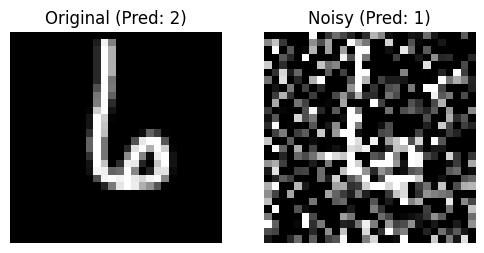

In [33]:

idx = np.random.randint(len(X_test))
original_img = X_test[idx]
original_label = y_test[idx]

noise = np.random.normal(0, 0.5, original_img.shape)
noisy_img = np.clip(original_img + noise, 0, 1)

original_pred = np.argmax(classifier.predict(original_img[np.newaxis, ...]))
noisy_pred = np.argmax(classifier.predict(noisy_img[np.newaxis, ...]))

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(original_img.squeeze(), cmap="gray")
plt.title(f"Original (Pred: {original_pred})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img.squeeze(), cmap="gray")
plt.title(f"Noisy (Pred: {noisy_pred})")
plt.axis("off")

plt.show()


In [34]:
def build_adversarial_model(base_model):
    
    base_model.trainable = False  

    noise_input = Input(shape=(1,))
    
    adversarial_noise = Dense(28 * 28, use_bias=False, kernel_regularizer=l2(0.01))(noise_input)
    adversarial_noise = Lambda(lambda x: tf.reshape(x, (-1, 28, 28, 1)))(adversarial_noise)

    adversarial_img = Input(shape=(28, 28, 1))
    perturbed_img = Lambda(lambda x: tf.clip_by_value(x[0] + x[1], 0.0, 1.0))([adversarial_img, adversarial_noise])

    output = base_model(perturbed_img)

    model = Model([adversarial_img, noise_input], output)
    return model


adv_model = build_adversarial_model(classifier)


In [35]:
def non_targeted_loss(y_true, y_pred):
    return -categorical_crossentropy(y_true, y_pred)

adv_model.compile(optimizer='adam', loss=non_targeted_loss, metrics=['accuracy'])


In [37]:
adv_model.summary()


Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 dense_13 (Dense)               (None, 784)          784         ['input_7[0][0]']                
                                                                                                  
 input_8 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 lambda (Lambda)                (None, 28, 28, 1)    0           ['dense_13[0][0]']               
                                                                                            

1/1 [==============================] - 0s 79ms/step


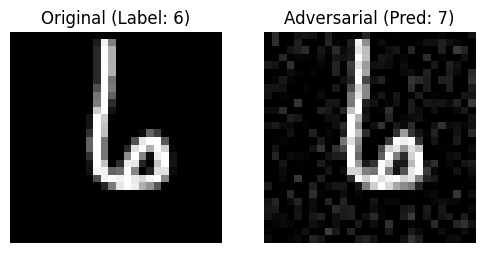

In [38]:

X_sample = X_test[idx:idx+1]
y_sample = y_test_cat[idx:idx+1]

dummy_noise_input = np.ones((1, 1))  

adv_model.fit([X_sample, dummy_noise_input], y_sample, epochs=100, verbose=0)

adv_noise = adv_model.get_layer("dense_13").get_weights()[0].reshape(28, 28, 1)
adv_img = np.clip(X_sample + adv_noise, 0, 1)

adv_pred = np.argmax(classifier.predict(adv_img))

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(X_sample.squeeze(), cmap="gray")
plt.title(f"Original (Label: {y_test[idx]})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(adv_img.squeeze(), cmap="gray")
plt.title(f"Adversarial (Pred: {adv_pred})")
plt.axis("off")

plt.show()


1/1 [==============================] - 0s 39ms/step


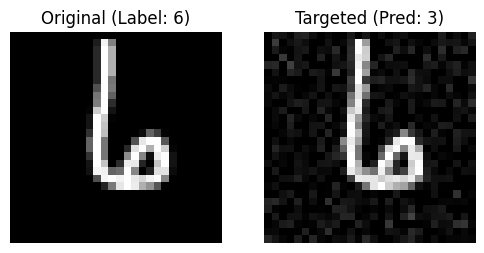

In [39]:

target_label = 3
y_target = keras.utils.to_categorical([target_label], num_classes=10)

adv_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

adv_model.fit([X_sample, dummy_noise_input], y_target, epochs=100, verbose=0)

adv_noise = adv_model.get_layer("dense_13").get_weights()[0].reshape(28, 28, 1)
targeted_adv_img = np.clip(X_sample + adv_noise, 0, 1)

targeted_adv_pred = np.argmax(classifier.predict(targeted_adv_img))

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(X_sample.squeeze(), cmap="gray")
plt.title(f"Original (Label: {y_test[idx]})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(targeted_adv_img.squeeze(), cmap="gray")
plt.title(f"Targeted (Pred: {targeted_adv_pred})")
plt.axis("off")

plt.show()
